# 🏨 Phase 3 — Sentiment Analysis
**Goal:** Analyze the sentiment of guest reviews using VADER and compare with numerical scores  
**Tools:** NLTK VADER · TextBlob · Word Clouds

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load Data

In [2]:
df = pd.read_csv(r"C:\Users\dimma\OneDrive\Υπολογιστής\Hotel 515\Hotel_Reviews.csv")
df['Negative_Review'] = df['Negative_Review'].replace('No Negative', '')
df['Positive_Review'] = df['Positive_Review'].replace('No Positive', '')
df['Hotel_Country'] = df['Hotel_Address'].apply(lambda x: x.split()[-1])

# Create combined review text
df['full_review'] = (df['Positive_Review'] + ' ' + df['Negative_Review']).str.strip()

# Work on a sample for speed (remove sample() for full analysis)
sample = df.sample(30000, random_state=42).copy()

print(f'✅ Working sample: {len(sample):,} reviews')

✅ Working sample: 30,000 reviews


## 3. VADER Sentiment Scoring

In [3]:
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    if not isinstance(text, str) or len(text) < 3:
        return 0
    return sia.polarity_scores(text)['compound']

sample['pos_vader']  = sample['Positive_Review'].apply(get_vader_sentiment)
sample['neg_vader']  = sample['Negative_Review'].apply(get_vader_sentiment)
sample['full_vader'] = sample['full_review'].apply(get_vader_sentiment)

# Sentiment labels
def label_sentiment(score):
    if score >= 0.05:  return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

sample['sentiment_label'] = sample['full_vader'].apply(label_sentiment)

print('✅ VADER scoring complete')
print(sample['sentiment_label'].value_counts())

✅ VADER scoring complete
sentiment_label
Positive    22735
Negative     3932
Neutral      3333
Name: count, dtype: int64


## 4. Sentiment Distribution

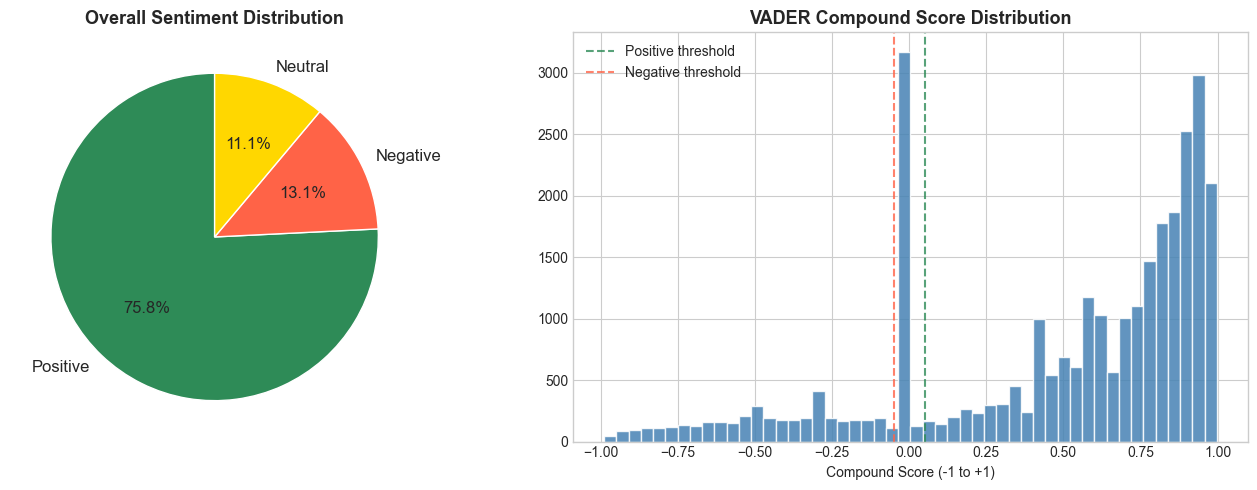

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sent_counts = sample['sentiment_label'].value_counts()
colors = ['seagreen', 'tomato', 'gold']
axes[0].pie(sent_counts.values, labels=sent_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Sentiment Distribution', fontsize=13, fontweight='bold')

# VADER score histogram
axes[1].hist(sample['full_vader'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0.05, color='seagreen', linestyle='--', alpha=0.8, label='Positive threshold')
axes[1].axvline(-0.05, color='tomato', linestyle='--', alpha=0.8, label='Negative threshold')
axes[1].set_title('VADER Compound Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Compound Score (-1 to +1)')
axes[1].legend()

plt.tight_layout()

plt.show()

## 5. Sentiment vs Reviewer Score (Correlation)

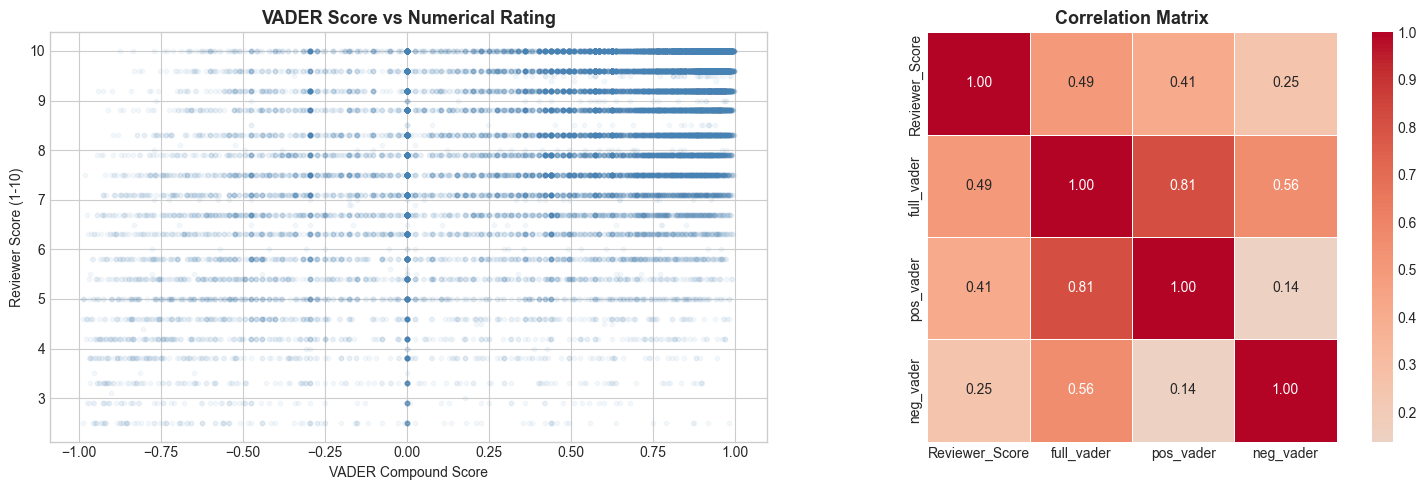

📊 Correlation (VADER vs Score): 0.492


In [6]:
# Correlation between VADER and numerical score
corr = sample[['Reviewer_Score', 'full_vader', 'pos_vader', 'neg_vader']].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
axes[0].scatter(sample['full_vader'], sample['Reviewer_Score'],
                alpha=0.05, color='steelblue', s=10)
axes[0].set_title('VADER Score vs Numerical Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Reviewer Score (1-10)')

# Correlation heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()

print(f'📊 Correlation (VADER vs Score): {sample["full_vader"].corr(sample["Reviewer_Score"]):.3f}')

## 6. Mismatch Detection — Says Good, Rates Low (and vice versa)

In [7]:
# Guests who write positive text but give low scores
hidden_dissatisfied = sample[
    (sample['full_vader'] > 0.3) &
    (sample['Reviewer_Score'] < 6)
].copy()

# Guests who write negative text but give high scores
hidden_satisfied = sample[
    (sample['full_vader'] < -0.1) &
    (sample['Reviewer_Score'] > 8)
].copy()

print(f'⚠️  Positive text BUT low score: {len(hidden_dissatisfied):,} reviews')
print(f'✅  Negative text BUT high score: {len(hidden_satisfied):,} reviews')
print()
print('Sample "Hidden Dissatisfied" reviews:')
print(hidden_dissatisfied[['Negative_Review', 'Reviewer_Score']].head(3).to_string())

⚠️  Positive text BUT low score: 913 reviews
✅  Negative text BUT high score: 929 reviews

Sample "Hidden Dissatisfied" reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 Negative_Review  Reviewer_Score
195089                                                                                                                

## 7. Word Clouds — Positive vs Negative

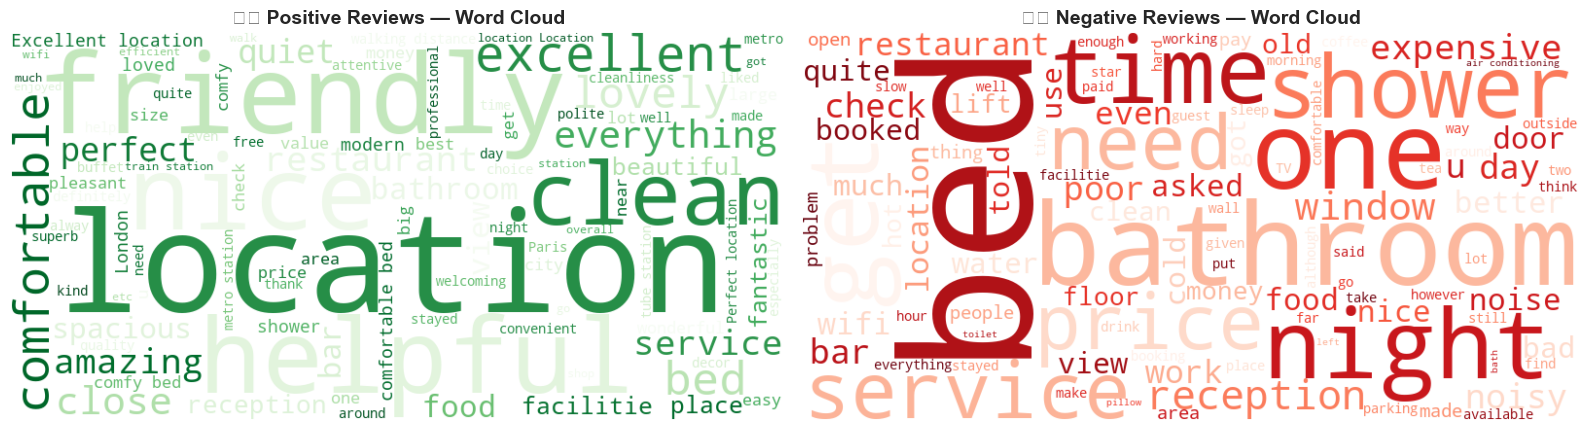

In [10]:
stop_words = set(stopwords.words('english'))
extra = {'hotel', 'room', 'nothing', 'no', 'not', 'really', 'also', 'would',
         'like', 'stay', 'staff', 'bit', 'little', 'just', 'good', 'great','rooms','could','breakfast','small'}
stop_words.update(extra)

pos_text = ' '.join(sample[sample['Positive_Review'].str.len() > 5]['Positive_Review'].dropna())
neg_text = ' '.join(sample[sample['Negative_Review'].str.len() > 5]['Negative_Review'].dropna())

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', stopwords=stop_words, max_words=100)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', stopwords=stop_words, max_words=100)

wc_pos.generate(pos_text)
wc_neg.generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☀️ Positive Reviews — Word Cloud', fontsize=14, fontweight='bold')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('⚠️ Negative Reviews — Word Cloud', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

## 8. Sentiment Trend Over Time

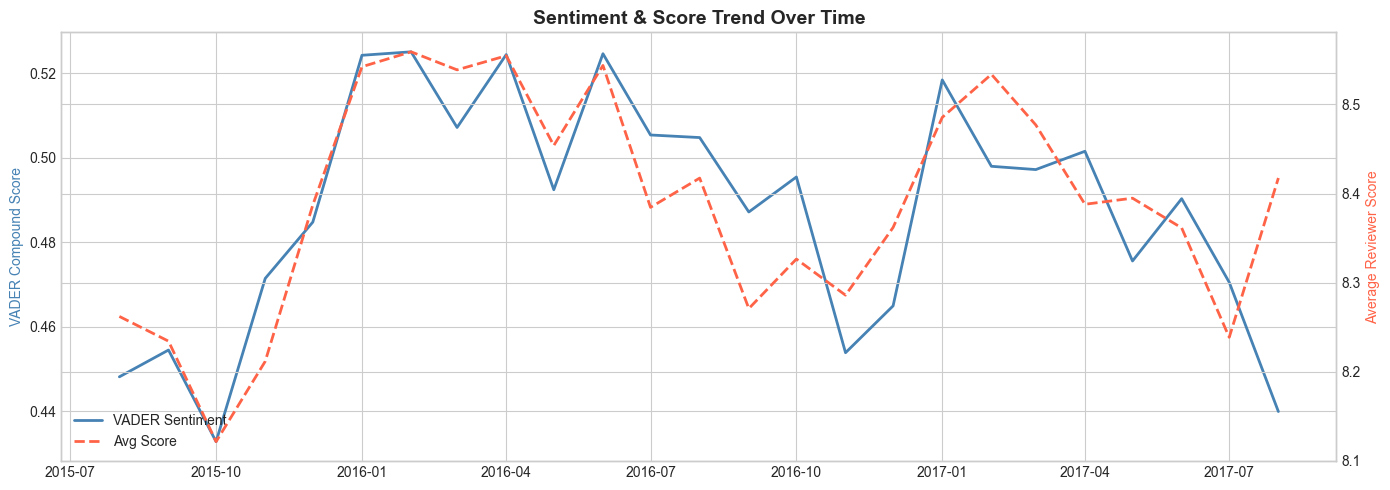

✅ Phase 3 Complete! → Proceed to 04_Guest_Segmentation.ipynb


In [12]:
sample['Review_Date'] = pd.to_datetime(sample['Review_Date'])
sample['YearMonth'] = sample['Review_Date'].dt.to_period('M')

monthly_sent = sample.groupby('YearMonth').agg(
    avg_vader=('full_vader', 'mean'),
    avg_score=('Reviewer_Score', 'mean')
).reset_index()
monthly_sent['YearMonth_dt'] = monthly_sent['YearMonth'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly_sent['YearMonth_dt'], monthly_sent['avg_vader'],
         color='steelblue', linewidth=2, label='VADER Sentiment')
ax2.plot(monthly_sent['YearMonth_dt'], monthly_sent['avg_score'],
         color='tomato', linewidth=2, linestyle='--', label='Avg Score')

ax1.set_title('Sentiment & Score Trend Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel('VADER Compound Score', color='steelblue')
ax2.set_ylabel('Average Reviewer Score', color='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()

plt.show()

print('✅ Phase 3 Complete! → Proceed to 04_Guest_Segmentation.ipynb')